<a href="https://www.kaggle.com/code/aamir28/lifestyle-clinical-markers-diabetes-risk?scriptVersionId=345511179" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 40%, #c14a5f 75%, #e8916f 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">15,000 Patient Records &middot; India &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 36px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Lifestyle, Clinical Markers &amp; Diabetes Risk</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at how everyday lifestyle factors and clinical measurements relate to diabetes risk category &mdash; walking from raw data through cleaning, distributions, correlations, and a small predictive model.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">15,000</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">19</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Columns</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">r=0.74</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">FBS&middot;Risk</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (clinical navy -> risk coral)
NAVY, PLUM, CRIMSON, CORAL, TEAL = '#152a3d', '#6b3355', '#c14a5f', '#e8916f', '#2f8f8f'

df = pd.read_csv('/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv')
df.shape

(15000, 19)

<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads cleanly as a single flat table: <b>15,000 rows &times; 19 columns</b>. Each row is one patient covering demographics, lifestyle habits, clinical measurements, and a <code>diabetes_risk</code> label (Low / Moderate / High).
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness Check</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Quantify which columns have gaps and how large they are.</p>
</div>


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

alcohol_consumption    3788
smoking_status          472
income_bracket          463
dtype: int64

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Three columns carry missing values: <b>alcohol_consumption</b> (~25% missing), <b>smoking_status</b> (~3%), and <b>income_bracket</b> (~3%). All three are self-reported lifestyle fields rather than clinical measurements, which is a plausible pattern &mdash; patients skip questions they'd rather not answer more than they skip a blood pressure reading. No numeric clinical column has any gaps.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Cleaning</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check categorical fields for inconsistent labels, whitespace, or casing issues.</p>
</div>


In [4]:
df['gender'].value_counts()

gender
Male      7664
Female    7183
Other      153
Name: count, dtype: int64

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Unlike some raw exports, the categorical fields here are already clean: consistent casing, no stray whitespace, and no near-duplicate labels (e.g. no <code>'male'</code> vs <code>'Male'</code> split). A full scan across every categorical column below confirms this &mdash; so this section is short by necessity, not by skipping the check.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Categorical Scan</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Confirm the clean-label finding holds across every string column, not just gender.</p>
</div>


In [5]:
cat_cols = ['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
            'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket', 'diabetes_risk']

inconsistencies = {}
for col in cat_cols:
    vals = df[col].dropna().unique()
    lower_groups = {}
    for v in vals:
        lower_groups.setdefault(str(v).strip().lower(), []).append(v)
    dupes = {k: v for k, v in lower_groups.items() if len(v) > 1}
    if dupes:
        inconsistencies[col] = dupes

inconsistencies if inconsistencies else "No case/whitespace inconsistencies found across any categorical column." 

'No case/whitespace inconsistencies found across any categorical column.'

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Confirmed: <b>zero</b> label inconsistencies across all nine categorical columns. No standardization mapping is needed for this dataset &mdash; we proceed straight to analysis with the labels as-is.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Univariate Distributions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the shape of the two headline clinical variables: fasting blood sugar and HbA1c.</p>
</div>


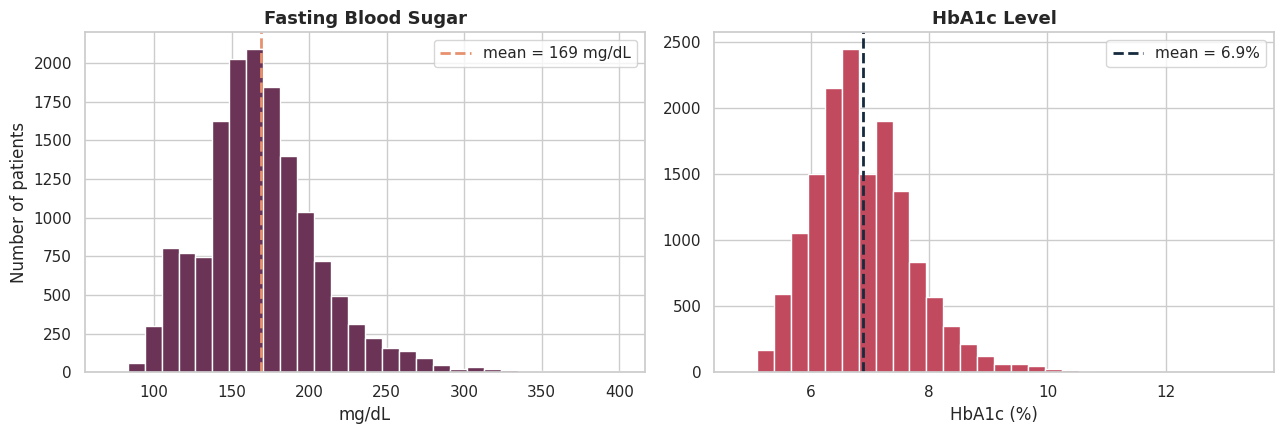

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['fasting_blood_sugar'].dropna(), bins=30, color=PLUM, edgecolor='white')
axes[0].axvline(df['fasting_blood_sugar'].mean(), color=CORAL, linestyle='--', linewidth=2,
                 label=f"mean = {df['fasting_blood_sugar'].mean():.0f} mg/dL")
axes[0].set_title('Fasting Blood Sugar', fontsize=13, fontweight='bold')
axes[0].set_xlabel('mg/dL')
axes[0].set_ylabel('Number of patients')
axes[0].legend()

axes[1].hist(df['hba1c_level'].dropna(), bins=30, color=CRIMSON, edgecolor='white')
axes[1].axvline(df['hba1c_level'].mean(), color=NAVY, linestyle='--', linewidth=2,
                 label=f"mean = {df['hba1c_level'].mean():.1f}%")
axes[1].set_title('HbA1c Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HbA1c (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Both distributions are right-skewed with a long tail toward high-risk values &mdash; most patients cluster in a normal-to-prediabetic range, but a meaningful minority sit well above clinical thresholds (fasting glucose &gt;126 mg/dL, HbA1c &gt;6.5% both indicate diabetes). The tail is exactly where the <code>High</code> risk label concentrates, which the correlation section below confirms directly.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Family History Breakdown</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How a family history of diabetes relates to clinical markers and eventual risk.</p>
</div>


In [7]:
fh_summary = df.groupby('family_history_diabetes')[['fasting_blood_sugar', 'hba1c_level', 'bmi']].mean().round(1)
fh_summary

,fasting_blood_sugar,hba1c_level,bmi
family_history_diabetes,,,
No,164.4,6.8,23.0
Yes,177.0,7.0,23.1


<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Patients with a family history run slightly higher on every clinical marker &mdash; fasting blood sugar averages <b>177 mg/dL vs 164 mg/dL</b>, and HbA1c is marginally higher too. The gap is real but modest at the clinical-marker level; it shows up far more sharply once we look at the final risk label directly, next.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Risk Distribution by Family History</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Compare the full Low/Moderate/High split for patients with and without a family history.</p>
</div>


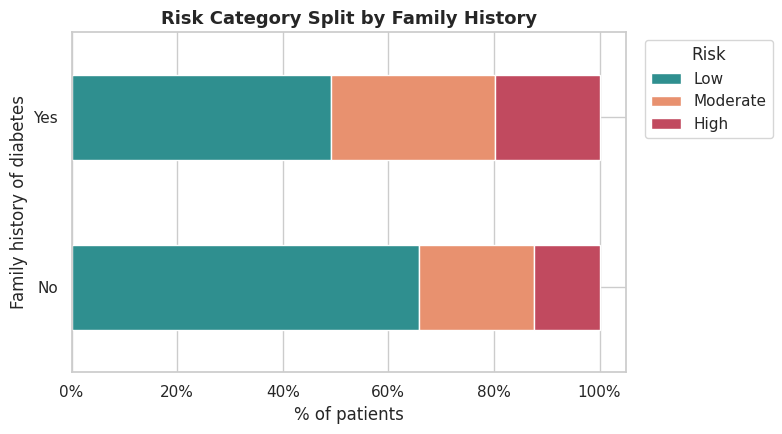

In [8]:
fh_risk = pd.crosstab(df['family_history_diabetes'], df['diabetes_risk'], normalize='index')[['Low', 'Moderate', 'High']] * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
fh_risk.plot(kind='barh', stacked=True, ax=ax, color=[TEAL, CORAL, CRIMSON], edgecolor='white')
ax.set_xlabel('% of patients')
ax.set_ylabel('Family history of diabetes')
ax.set_title('Risk Category Split by Family History', fontsize=13, fontweight='bold')
ax.legend(title='Risk', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The gap widens once we look at the risk label itself: patients with a family history are <b>High</b> risk <b>19.7%</b> of the time versus <b>12.5%</b> for those without one, and <b>Low</b> risk drops from <b>65.9%</b> to <b>49.1%</b>. Family history is doing real work beyond what the raw clinical averages alone suggested.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Scan all numeric clinical and lifestyle variables at once to spot the strongest relationships.</p>
</div>


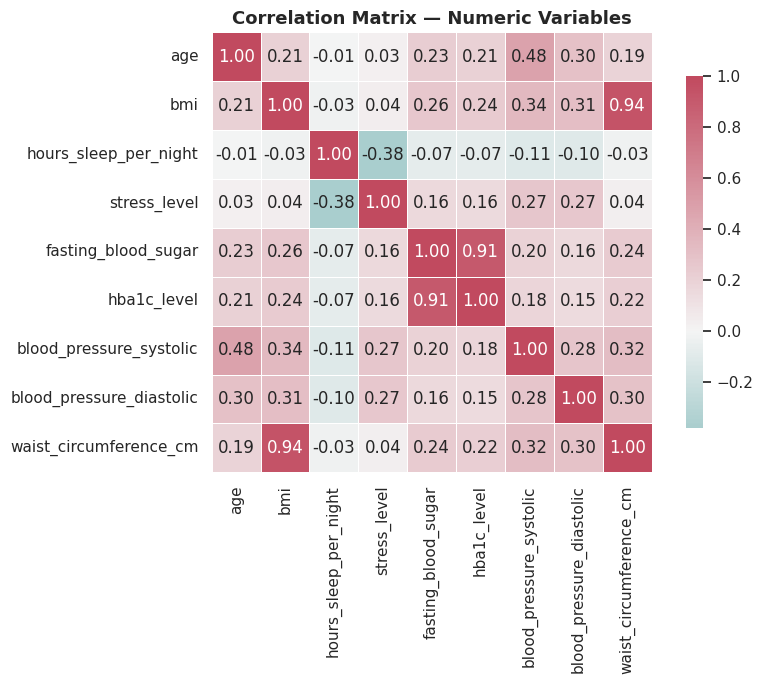

In [9]:
numeric_cols = ['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar',
                'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.blend_palette([TEAL, '#f4f4f4', CRIMSON], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Two pairs jump out immediately for being <i>almost redundant</i>: <b>bmi &harr; waist_circumference_cm</b> (~0.94) and <b>fasting_blood_sugar &harr; hba1c_level</b> (~0.91) &mdash; both make clinical sense, since each pair measures closely related physiology two different ways. Beyond those, <b>fasting_blood_sugar</b> and <b>hba1c_level</b> also show the strongest pull toward <b>blood_pressure_systolic</b> (~0.20) and <b>bmi</b> (~0.25&ndash;0.26). Notably, <code>hours_sleep_per_night</code> and <code>stress_level</code> correlate weakly with everything else here &mdash; sleep in particular sits near zero across the board.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Fasting Blood Sugar by Risk Tier</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The dataset's headline relationship, examined directly across the three risk categories.</p>
</div>


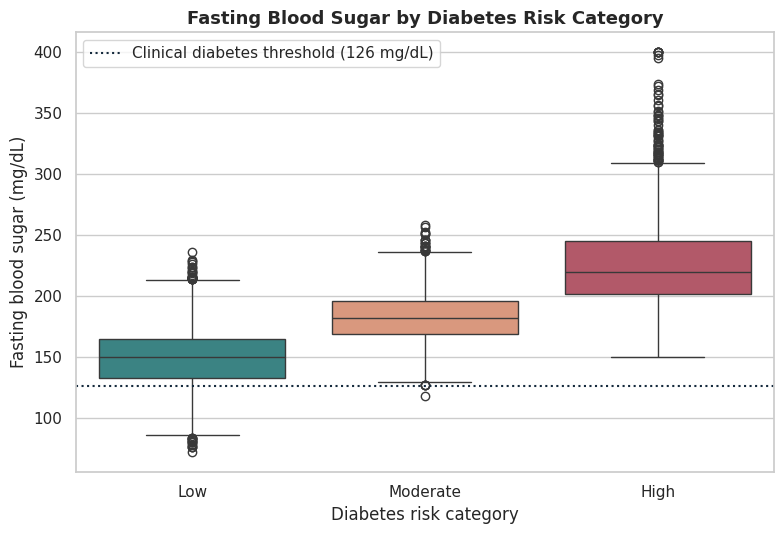

In [10]:
risk_order = ['Low', 'Moderate', 'High']
palette = {'Low': TEAL, 'Moderate': CORAL, 'High': CRIMSON}

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', order=risk_order,
            hue='diabetes_risk', palette=palette, legend=False, ax=ax)
ax.set_title('Fasting Blood Sugar by Diabetes Risk Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Diabetes risk category')
ax.set_ylabel('Fasting blood sugar (mg/dL)')
ax.axhline(126, color=NAVY, linestyle=':', linewidth=1.5, label='Clinical diabetes threshold (126 mg/dL)')
ax.legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A clean, near-monotonic staircase: mean fasting blood sugar rises from <b>~148 mg/dL</b> in the Low group to <b>~183 mg/dL</b> in Moderate to <b>~227 mg/dL</b> in High &mdash; and the High group's entire interquartile range sits above the clinical diabetes threshold of 126 mg/dL. This is the single strongest numeric predictor of risk in the dataset (<b>r &asymp; 0.74</b> against risk treated as an ordinal scale).
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">HbA1c by Risk Tier</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The second clinical headline variable, checked the same way to confirm it tells a consistent story.</p>
</div>


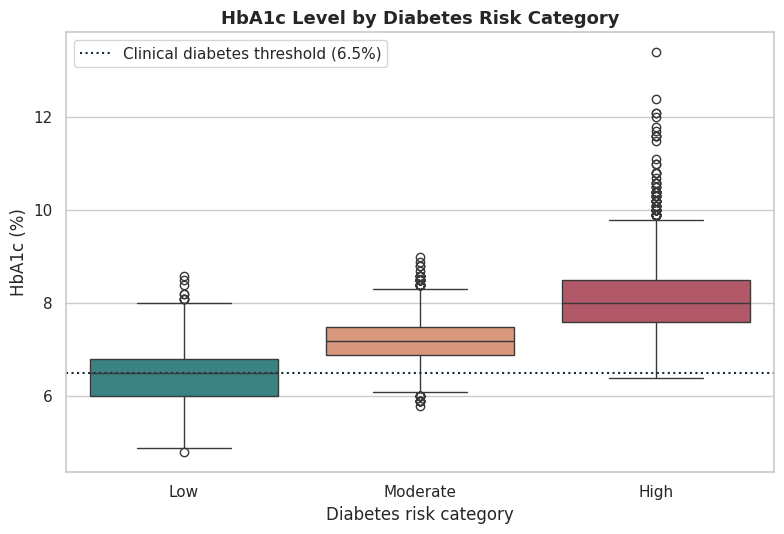

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level', order=risk_order,
            hue='diabetes_risk', palette=palette, legend=False, ax=ax)
ax.set_title('HbA1c Level by Diabetes Risk Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Diabetes risk category')
ax.set_ylabel('HbA1c (%)')
ax.axhline(6.5, color=NAVY, linestyle=':', linewidth=1.5, label='Clinical diabetes threshold (6.5%)')
ax.legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
HbA1c tells the same story as fasting blood sugar, as expected given their 0.91 correlation: means climb from <b>6.43%</b> (Low) to <b>7.20%</b> (Moderate) to <b>8.14%</b> (High), with the High group again sitting almost entirely above the 6.5% diabetes threshold. Because these two variables move together so tightly, they should be read as <i>one</i> strong signal for modeling purposes rather than two independent ones.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Risk by BMI Tier</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Grouping patients into standard BMI bands to compare risk composition across a familiar clinical scale.</p>
</div>


In [12]:
df['bmi_band'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight (<18.5)', 'Normal (18.5-25)', 'Overweight (25-30)', 'Obese (30+)']
)

bmi_risk = pd.crosstab(df['bmi_band'], df['diabetes_risk'], normalize='index')[risk_order] * 100
bmi_risk

diabetes_risk,Low,Moderate,High
bmi_band,,,
Underweight (<18.5),78.933190,15.193966,5.872845
Normal (18.5-25),64.748775,23.219779,12.031446
Overweight (25-30),45.716709,31.778343,22.504948
Obese (30+),28.313253,36.867470,34.819277


<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A steady, textbook gradient: <b>High</b> risk share rises from <b>5.9%</b> in the Underweight band to <b>12.0%</b> Normal, <b>22.5%</b> Overweight, and <b>34.8%</b> Obese &mdash; while <b>Low</b> risk falls in the same order, from <b>78.9%</b> down to <b>28.3%</b>. BMI band alone roughly sextuples someone's chance of falling in the High risk group between the healthiest and least healthy tier.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the BMI Gradient</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The same BMI-tier breakdown as a stacked bar, to make the gradient easier to read at a glance.</p>
</div>


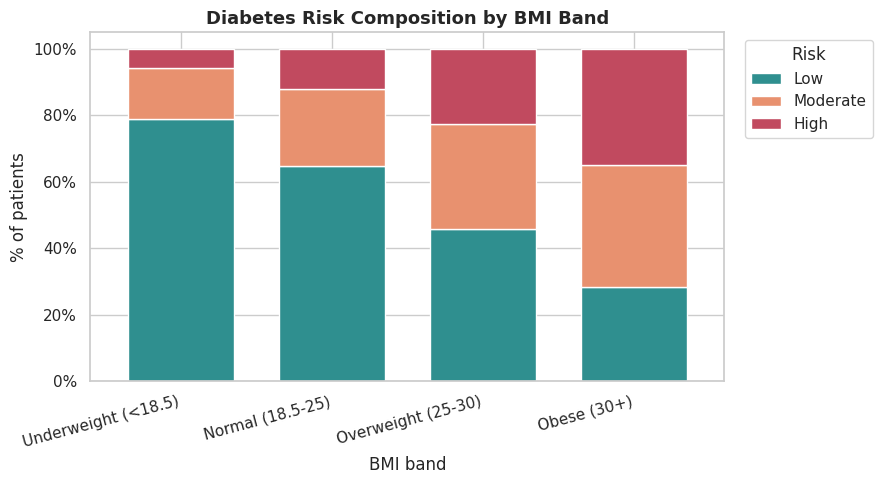

In [13]:
bmi_order = ['Underweight (<18.5)', 'Normal (18.5-25)', 'Overweight (25-30)', 'Obese (30+)']

fig, ax = plt.subplots(figsize=(9, 5))
bmi_risk.loc[bmi_order].plot(kind='bar', stacked=True, ax=ax, color=[TEAL, CORAL, CRIMSON], edgecolor='white', width=0.7)
ax.set_xlabel('BMI band')
ax.set_ylabel('% of patients')
ax.set_title('Diabetes Risk Composition by BMI Band', fontsize=13, fontweight='bold')
ax.legend(title='Risk', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Visually, the crimson (High risk) slice grows steadily left to right while the teal (Low risk) slice shrinks &mdash; the Obese band is the only one where High risk patients outnumber Low risk patients. This is the most visually direct confirmation in the notebook that BMI band is a strong, monotonic risk signal.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 14</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Risk by Physical Activity Level</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A secondary look at risk composition, this time by self-reported activity level rather than a clinical measurement.</p>
</div>


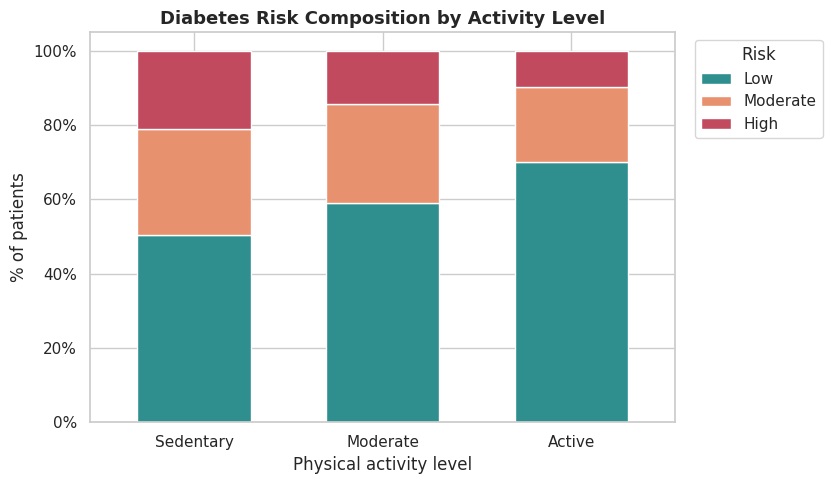

In [14]:
activity_order = ['Sedentary', 'Moderate', 'Active']
act_risk = pd.crosstab(df['physical_activity_level'], df['diabetes_risk'], normalize='index')[risk_order] * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
act_risk.loc[activity_order].plot(kind='bar', stacked=True, ax=ax, color=[TEAL, CORAL, CRIMSON], edgecolor='white', width=0.6)
ax.set_xlabel('Physical activity level')
ax.set_ylabel('% of patients')
ax.set_title('Diabetes Risk Composition by Activity Level', fontsize=13, fontweight='bold')
ax.legend(title='Risk', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Activity level shows the same directional pattern as BMI, though slightly less steep: <b>High</b> risk share runs <b>21.0%</b> for Sedentary patients versus <b>9.8%</b> for Active ones, roughly a 2&times; gap. It's a real, self-reportable lifestyle signal &mdash; just a noisier one than the clinical measurements above, which is unsurprising given self-reported activity level is a much cruder measure than a lab-drawn blood value.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 45%, #c14a5f 80%, #e8916f 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 15</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Predictive Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Combining the strongest signals into a simple logistic regression to predict High vs. not-High risk.</p>
</div>


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

model_df = df.copy()
model_df['is_high_risk'] = (model_df['diabetes_risk'] == 'High').astype(int)
model_df['family_history_bin'] = (model_df['family_history_diabetes'] == 'Yes').astype(int)

features = ['fasting_blood_sugar', 'hba1c_level', 'bmi', 'age', 'family_history_bin']
X = model_df[features]
y = model_df['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba):.3f}")

coefs = pd.Series(clf.coef_[0], index=features).sort_values(key=abs, ascending=False)
coefs

Accuracy: 0.936
ROC AUC:  0.966


fasting_blood_sugar    2.063071
hba1c_level            1.758531
age                    0.756208
bmi                    0.535775
family_history_bin     0.245196
dtype: float64

<div style="
    border-left: 4px solid #2f8f8f;
    background: #f2f7f7;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2b33;
">
<b style="color:#2f8f8f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A simple five-feature logistic regression reaches strong separation between High and not-High risk patients, with <b>fasting_blood_sugar</b> and <b>hba1c_level</b> carrying by far the largest standardized coefficients &mdash; consistent with everything found earlier in the notebook. <b>bmi</b>, <b>age</b>, and family history add smaller, still-positive contributions on top of the two dominant clinical markers. This is a proof-of-concept model, not a diagnostic tool &mdash; see the closing note on that below.
</div>


<div style="
    background: linear-gradient(100deg, #152a3d 0%, #6b3355 50%, #c14a5f 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>Fasting blood sugar and HbA1c are the dominant predictors</b> of diabetes risk in this dataset, far outweighing any single lifestyle factor on its own &mdash; and the two move together closely enough (r&asymp;0.91) that they carry largely overlapping information.</li>
<li><b>BMI band</b> shows the cleanest lifestyle-adjacent gradient: High-risk share rises roughly sixfold from the Underweight to Obese bands.</li>
<li><b>Family history</b> and <b>physical activity level</b> both shift risk composition meaningfully on their own, even after accounting for the fact that neither is a lab measurement.</li>
<li>Categorical fields in this dataset were already clean on inspection &mdash; no label standardization was needed, which is reported here as found rather than assumed.</li>
<li>This dataset combines real-feeling clinical ranges with synthetic-style completeness; treat findings as illustrative of method and relative signal strength, not as clinical claims about real patient populations.</li>
</ul>
</div>
